## Installing Dependencies

In [97]:
# %%capture --no-stderr
# %pip install langchain-opentutorial langchain_community pypdf faiss-cpu sentence_transformers langgraph langchain_huggingface langchain_core langsmith langchain

In [98]:
from dotenv import load_dotenv
load_dotenv()

True

In [99]:
from langchain_huggingface import HuggingFaceEmbeddings
from sentence_transformers import SentenceTransformer

embedding_model = HuggingFaceEmbeddings(model_name ="sentence-transformers/all-MiniLM-L6-v2" )

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10058.28it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [100]:
from langchain_huggingface import HuggingFaceEndpoint,ChatHuggingFace
ll = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.3-70B-Instruct",
    task="text-generation",

)
model1 = ChatHuggingFace(llm=ll,temperature = 0)
result = model1.invoke("hello?")
print(result.content)

Hello. It's nice to meet you. Is there something I can help you with, or would you like to chat?


## PDF-Retrieval chain

In [101]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

In [102]:
loader = PyPDFLoader("C:/Users/venne/Videos/Screenshots/Documents/CRAG/data/sample.pdf")
docs = loader.load()
print(len(docs))

splitter = RecursiveCharacterTextSplitter(
    chunk_size = 500,
    chunk_overlap = 50
)

chunks = splitter.split_documents(docs)
print(len(chunks))

27
187


In [103]:
vector_store = FAISS.from_documents(chunks, embedding_model)

In [104]:
vector_store.index_to_docstore_id

{0: '83274a12-1237-4826-b375-1326d97438d3',
 1: '6d6982af-234b-41a8-8c36-a2f0dff5e4d0',
 2: 'b3b5e37c-8c52-486b-a9bc-d49d4cb4277c',
 3: '5b27986d-aa43-4fb4-8f08-760f2bad9975',
 4: '45b6c34f-f56b-48f5-ab7b-81bfdbaeb790',
 5: '5d027f86-3bf3-4a31-b1e6-da3c20334ad5',
 6: '51d4b43b-f7de-4624-8193-95005ce1a2e5',
 7: '0815fd2a-03c5-4662-935a-0fb467106d74',
 8: '1a28969a-4064-49a6-b9e7-3e61ffc03a8a',
 9: '1e97f8cc-7b3f-42c3-934a-357f9f7f6282',
 10: 'daf0900f-91c1-4fe2-8ee5-db5d0ef671db',
 11: 'd811c5bd-35cb-4c26-a1ef-fb71952fb035',
 12: '98d9f1fe-d4c0-4806-afab-5cd85beaf759',
 13: '28fedf10-bc78-437c-9fa0-b0b666b8fb06',
 14: '510c13e6-f992-41f3-804c-9348e51ce16f',
 15: '5bea58d0-ab1a-457a-970e-fd134007fcfc',
 16: 'e30193a0-cdbe-4f6c-ac07-6f4b4f6e5bee',
 17: '7db5ee5e-42aa-4f3d-81a8-34c6eeffd18d',
 18: '701888ff-2fd9-4259-968f-92ed64d04c23',
 19: '7a18355d-d16b-4a81-b7df-a26ddab428cf',
 20: '368bcc68-901b-4bf2-aaeb-b208faa9b12e',
 21: 'e53c7732-23d2-4e71-a616-d3c99f75071c',
 22: 'a675fb40-d72b-

In [106]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 2})

In [107]:
question = "what are Autoregressive language Models?"

In [108]:
docs = retriever.invoke(question)
print(docs)

[Document(id='dbd0b007-4dac-4ee5-8a79-cf117170195b', metadata={'producer': 'pdfTeX-1.40.21', 'creator': 'LaTeX with hyperref', 'creationdate': '2026-01-06T08:23:15-08:00', 'author': '', 'title': '', 'subject': '', 'keywords': '', 'moddate': '2026-01-06T08:23:15-08:00', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) kpathsea version 6.3.2', 'source': 'C:/Users/venne/Videos/Screenshots/Documents/CRAG/data/sample.pdf', 'total_pages': 27, 'page': 25, 'page_label': '26'}, page_content='through a softmax to generate word probabilities.\n• Transformer-based language models have a wide context window (200K to-\nkens or even more for very large models with special mechanisms) allowing\nthem to draw on enormous amounts of context to predict upcoming words.\n• There are various computational tricks for making large language models\nmore efﬁcient, such as theKV cache and parameter-efﬁcient ﬁnetuning.\nHistorical Notes'), Document(id='3cf4867

## Relevance Evaluation of Retrieved Documents

In [109]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser


system_prompt = """
You are a grader assessing whether a retrieved document is relevant to a user question.
If the document has content that matches or semantically relates to the question, say "yes".
If not, say "no".
Reply with only "yes" or "no" — nothing else.
"""

grade_prompt = ChatPromptTemplate.from_messages([
    ("system", system_prompt),
    ("human", "Retrieved document:\n\n{document}\n\nUser question: {question}"),
])

retrieval_grader_chain = grade_prompt | model1 | StrOutputParser()

output = retrieval_grader_chain.invoke({"document": docs, "question": question})
print(output)


no


## Answer Generation Chain

In [110]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "You are an assistant for question-answering tasks. "
        "Use the following pieces of retrieved context to answer the question. "
        "If you don't know the answer, just say that you don't know. "
        "Use three sentences maximum and keep the answer concise."
    )),
    ("human", "Question: {question}\n\nContext: {context}\n\nAnswer:"),
])

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

rag_chain = rag_prompt | model1 | StrOutputParser()


In [111]:
generation = rag_chain.invoke({"context": format_docs(docs), "question": question})
print(generation)

Autoregressive language models are a type of language model that generates text by predicting the next word based on the context of the previous words. They compute the probability of a word given the counts of its occurrence with the n− 1 prior words, with the context size being n− 1. Transformer-based language models are an example of autoregressive models, using a wide context window to predict upcoming words.


## Question Re-write

In [112]:

system = """
 You are a question re-writer that converts an input question to a better version that is optimized
for web search. Look at the input and try to reason about the underlying semantic intent / meaning.
Just give only rewritten question Dont give anything explanation.

"""

re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system",system),
        ("human","Here is the initial question :\n\n {question} \n Formulate an improved question.",),

    ]
)

question_rewriter = re_write_prompt | model1 | StrOutputParser()

In [113]:
# Run chain and output results
print(f'[Original question]: "{question}"')
print("[Query-rewrite]:", question_rewriter.invoke({"question": question}))

[Original question]: "what are Autoregressive language Models?"
[Query-rewrite]: What are autoregressive language models in natural language processing and how do they work?


## Web Search Tool

In [114]:
from langchain_tavily import TavilySearch
web_search_tool = TavilySearch(max_results = 3)

In [115]:
# Execute web search tool
results = web_search_tool.invoke({"query": question})
print(results)

{'query': 'what are Autoregressive language Models?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://medium.com/@zaiinn440/autoregressive-models-for-natural-language-processing-b95e5f933e1f', 'title': 'Autoregressive Models for Natural Language Processing - Medium', 'content': '# Autoregressive Models for Natural Language Processing | by Zain ul Abideen | Medium. # Autoregressive Models for Natural Language Processing. The Evolution of GPT: From GPT to GPT-2 to GPT-3. In this blog post, I will be discussing the Autoregressive models. First I will cover the basics of Autoregressive models which are common in all GPT models and then move toward the advancements in each successive model. In the previous blog post Attention Is All You Need: The Core Idea of the Transformer, I discussed the self-attention mechanism and Transformer architecture. In the context of natural language processing, autoregressive models are often applied to generate text or 

## State


In [116]:
from typing import Annotated , List , TypedDict

class AgentState(TypedDict):
  question : Annotated[str," The question to answer"]
  generation : Annotated[str , "The generation from the llm"]
  web_search : Annotated[str , "Whether to add search"] # yes or no
  documents : Annotated [ List[str] , " The documents received "]

## Node

In [ ]:
from langchain_core.documents import Document

def retrieve( state : AgentState) -> AgentState:
  print("Retrieve")

  question = state["question"]

  documents = retriever.invoke(question)
  return {"documents" : documents}


def generate(state : AgentState) -> AgentState:
  print( "Generate")

  question = state["question"]
  documents = state["documents"]

  generation = rag_chain.invoke({"context" : documents ,"question" : question })
  return {"generation" : generation}


def grade_documents(state: AgentState)->AgentState:
    print("\n CHECK DOCUMENT RELEVANCE TO QUESTION \n")
    question = state["question"]
    documents = state["documents"]

    # Filtered documents
    filtered_docs = []
    relevant_doc_count = 0

    for d in documents:
  
        score = retrieval_grader_chain.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score

        if grade == "yes":
            print(" GRADE: DOCUMENT RELEVANT ")
            # Add relevant documents to filtered_docs.
            filtered_docs.append(d)
            relevant_doc_count += 1
        else:
            print(" GRADE: DOCUMENT NOT RELEVANT ")
            continue

    
    web_search = "Yes" if relevant_doc_count == 0 else "No"
    return {"documents": filtered_docs, "web_search": web_search}

def query_rewrite(state : AgentState) -> AgentState:
  print(" Rewrite Query")
  question = state["question"]
  better_question = question_rewriter.invoke({"question" : question})
  print(better_question)
  return {"question": better_question}

def web_search(state: AgentState) -> AgentState:
    print("Web Search")

    question = state["question"]
    documents = state["documents"]

    docs = web_search_tool.invoke(question)


    if isinstance(docs, str):
        content = docs
    elif isinstance(docs, list):
        content = "\n".join(d["content"] if isinstance(d, dict) else str(d) for d in docs)
    else:
        content = str(docs)  

    web_results = Document(page_content=content)
    documents.append(web_results)

    return {"documents": documents}




## Function for conditional edges

In [118]:
def decide_to_generate(state:AgentState) -> AgentState:
  print(" Assess Graded Documents")
  web_search = state["web_search"]

  if web_search == "Yes" :
    print("All Documents are not relevant to question , Query Rewrite")
    return "query_rewrite"

  else:
    print("Decision : Generate")
    return "generate"


## Graph Creation

In [119]:
from langgraph.graph import END,StateGraph , START

graph = StateGraph(AgentState)
graph.add_node("retrieve" , retrieve)
graph.add_node("grade_documents",grade_documents)
graph.add_node("generate" , generate)
graph.add_node("query_rewrite" , query_rewrite)
graph.add_node("web_search_node" ,web_search)

graph.add_edge(START , "retrieve")
graph.add_edge("retrieve" , "grade_documents")

graph.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "query_rewrite" : "query_rewrite",
        "generate"  : "generate",
    },
)

graph.add_edge("query_rewrite","web_search_node")
graph.add_edge("web_search_node","generate")
graph.add_edge("generate" , END)

app = graph.compile()

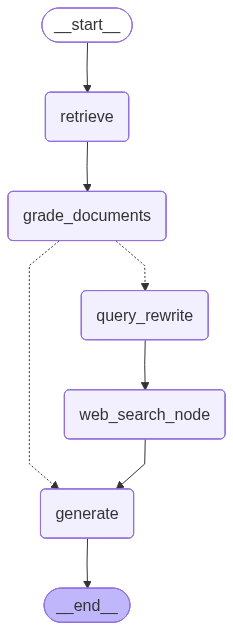

In [120]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

## Graph Execution


In [121]:
input = {
    "question": "What is Markov Assumption in N-grams?",
}

for output in app.stream(input):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("\n---\n")

print(value["generation"])


Retrieve
Output from node 'retrieve':

---


 CHECK DOCUMENT RELEVANCE TO QUESTION 

 GRADE: DOCUMENT NOT RELEVANT 
 GRADE: DOCUMENT NOT RELEVANT 
 Assess Graded Documents
All Documents are not relevant to question , Query Rewrite
Output from node 'grade_documents':

---

 Rewrite Query
What is the Markov assumption in the context of N-gram language models?
Output from node 'query_rewrite':

---

Web Search
Output from node 'web_search_node':

---

Generate
Output from node 'generate':

---

The Markov assumption in the context of N-gram language models states that to predict the next word, you only need a limited recent window of previous words, not the entire past. This means the probability of a word depends only on the probability of the n-previous words. The Markov chain is a mathematical system that transitions between states according to certain probabilities, where the probability of moving to the next state depends only on the current state.


In [122]:
input = {
    "question": "What are residual layers?",
}

for output in app.stream(input):
    for key, value in output.items():
        print(f"Output from node '{key}':")
        print("\n---\n")

print(value["generation"])

Retrieve
Output from node 'retrieve':

---


 CHECK DOCUMENT RELEVANCE TO QUESTION 

 GRADE: DOCUMENT RELEVANT 
 GRADE: DOCUMENT RELEVANT 
 Assess Graded Documents
Decision : Generate
Output from node 'grade_documents':

---

Generate
Output from node 'generate':

---

Residual layers refer to the residual stream in transformer blocks, where the input from the prior layer is passed up to the next layer. The output of different components, such as multi-head attention and feedforward layers, are added to this residual stream. This allows the network to learn and preserve important information from previous layers.
